Implement hierarchical clustering on sales_data_sample.csv dataset. Determine the number of
clusters using the elbow method.
Dataset link :
https://www.kaggle.com/datasets/kyanyoga/sample-sales-data

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

In [19]:
data = pd.read_csv("D:/KAUSTUBH/LP3 Final/sales_data_sample.csv", encoding="latin")

data.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [20]:
# Select relevant numeric features for clustering
numeric_data = data[['QUANTITYORDERED', 'PRICEEACH', 'SALES']]

In [21]:
# Handle missing values (if any) by dropping rows with NaN values
numeric_data = numeric_data.dropna()

In [22]:
# Scale the features for hierarchical clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

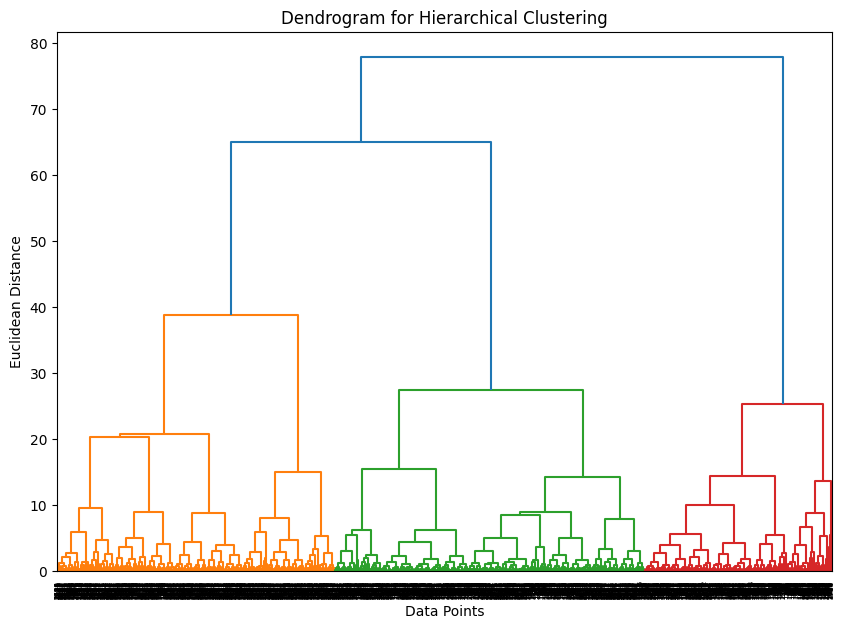

In [23]:
# Perform hierarchical clustering and plot the dendrogram
linked = linkage(scaled_data, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

### **Dendrogram**: 

A **dendrogram** is a tree-like diagram that is used to represent the hierarchical relationships between objects in **hierarchical clustering**. It shows how the clusters are formed by progressively merging or splitting them. The dendrogram illustrates the sequence of merges (or splits) at each step, and how similar the objects are to each other based on a chosen distance metric.

It is commonly used in **agglomerative hierarchical clustering**, where clusters are merged together step by step, starting with individual data points as separate clusters, and merging the most similar ones until all the data points belong to a single cluster.

### **Key Elements of a Dendrogram**:
1. **Leaves (at the bottom)**: Represent individual data points or objects. Each leaf is a separate data point initially.
2. **Branches (merging points)**: Represent the merging of clusters. The height at which two clusters merge indicates the **similarity** between them. The higher the merge, the less similar the two clusters are.
3. **Height/Distance**: The vertical axis represents the **distance** or **dissimilarity** between the clusters being merged. A higher height means that the two clusters being merged are less similar to each other.
4. **Nodes**: The internal nodes show where two clusters have been combined. The position of each node reflects how similar the two clusters are.

### **How to Read a Dendrogram**:

When reading a dendrogram, the key idea is to focus on the **distance** or **dissimilarity** between clusters and how they are merged. Here's how to interpret it:

1. **Cluster Merging**:
   - As you move up the tree, clusters are combined. At each step, the two most similar clusters (the closest in terms of distance) are merged.
   - The **height** at which two branches merge indicates how similar they are. **Lower merges** (closer to the bottom) suggest that the clusters are **more similar** to each other, while **higher merges** indicate **less similarity**.

2. **Choosing the Number of Clusters**:
   - You can decide how many clusters to form by cutting the dendrogram at a certain height. 
   - The number of clusters corresponds to how many branches are separated by the cut. For example, if you cut the dendrogram at a certain height and there are 3 separate branches, you can conclude that your data has 3 clusters.
   - A common technique is to make a **horizontal cut** across the dendrogram at a specific height that maximizes the difference between the clusters while minimizing the distance between points within clusters.

3. **Distance/Similarity**:
   - The **y-axis** of the dendrogram represents the **distance** or **dissimilarity** between clusters. If two data points or clusters merge at a low level (closer to the bottom), they are more similar. If they merge at a higher level, they are more different.
   - A **shorter branch** between clusters means that the clusters are similar, while a **longer branch** indicates that the clusters are relatively different.

### **Example of How to Read a Dendrogram**:
Suppose you have a dendrogram with 5 data points (A, B, C, D, E). Here's a step-by-step guide on how to read it:

1. **Start at the Bottom**: At the bottom, you see individual data points, each represented as a leaf (A, B, C, D, E).
   
2. **First Merge**: The first two clusters to be merged might be A and B, and they are joined at a **low distance** (close to the bottom), meaning they are very similar.

3. **Second Merge**: Next, clusters A-B and C might merge at a higher point (a slightly higher distance), suggesting that while A-B and C are similar to each other, they are not as close as A and B were.

4. **Final Merge**: Eventually, all the data points will be merged into one single cluster at the top of the tree. The height of the final merge indicates the total dissimilarity between the final two clusters.

5. **Choosing Clusters**: If you wanted to create **3 clusters**, you could cut the dendrogram at a certain height where you would get 3 branches, thus resulting in 3 distinct clusters.

### **Steps to Read the Dendrogram**:

1. **Look at the Leaves**: Identify the individual data points at the bottom of the dendrogram.
   
2. **Track the Merges**: Follow the branches upwards to see which clusters (data points) are merged at each step. The closer the branches are to the bottom, the more similar those clusters are.

3. **Determine Similarity**: Check the vertical distance at each merge. A lower merge means more similarity, a higher merge means less similarity.

4. **Decide the Number of Clusters**: Decide where you want to cut the dendrogram (based on the vertical distance). This cutting height determines the number of clusters. For example, if you cut below a point where there are 3 branches left, you will end up with 3 clusters.

### **Example of Dendrogram Visualization**:

Imagine a dataset with 5 data points: A, B, C, D, and E. Here's what a simplified dendrogram might look like:

```
           _________
          |         |
        __|__     __|__
       |     |   |     |
     __|__  __|__|     |
    |    | |    | |     |
    A    B C    D E     |
                        |
                ________|
               |        |
              A-B   C-D-E
```

- At the very bottom, you see the individual data points: A, B, C, D, and E.
- The first merge happens between **A and B**, indicating they are the most similar.
- Next, **C** merges with **D** and **E**, suggesting that C is similar to D and E, but not as similar to A and B.
- Finally, all clusters are merged into one final cluster at the top.

If you wanted to form **2 clusters**, you would cut the dendrogram where the final merge happens (between A-B and C-D-E).

In [24]:
# Elbow method to determine the optimal number of clusters
distortions = []
K = range(2, 11)  # Start from 2 as 1 cluster distortion doesn't provide useful information
for k in K:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    model.fit(scaled_data)
    # Calculate the mean distance between each point and its assigned cluster's centroid
    labels = model.labels_
    centroids = [scaled_data[labels == i].mean(axis=0) for i in range(k)]
    distortion = sum(np.min(cdist(scaled_data, centroids, 'euclidean'), axis=1))
    distortions.append(distortion)

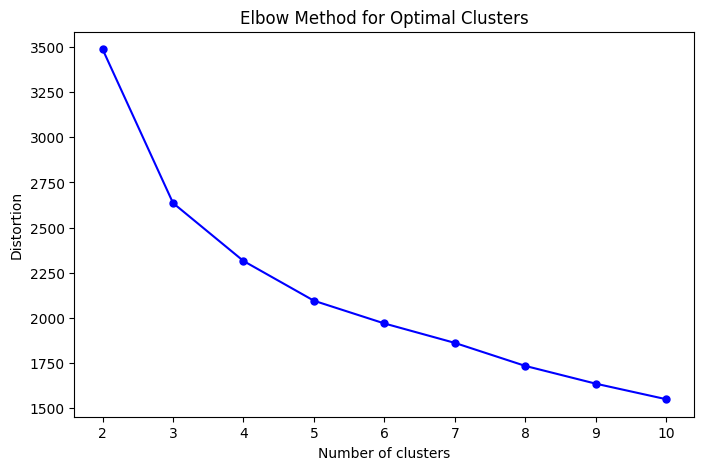

In [25]:
# Plot the elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K, distortions, 'bo-', markersize=5)
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

In [26]:
# Fit Agglomerative Clustering with the number of clusters determined (e.g., 3 based on elbow method observation)
optimal_k = 3  # Adjust this based on elbow plot observation if needed
hierarchical_cluster = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
data['Cluster'] = hierarchical_cluster.fit_predict(scaled_data)

In [27]:
# Show the first few rows with cluster labels
print(data[['QUANTITYORDERED', 'PRICEEACH', 'SALES', 'Cluster']].head())

   QUANTITYORDERED  PRICEEACH    SALES  Cluster
0               30      95.70  2871.00        2
1               34      81.35  2765.90        2
2               41      94.74  3884.34        1
3               45      83.26  3746.70        0
4               49     100.00  5205.27        1


### **Hierarchical Clustering**

**Hierarchical clustering** is a type of **unsupervised learning** algorithm used to group similar data points into clusters. The goal of hierarchical clustering is to build a **hierarchy** of clusters, often represented as a tree-like diagram called a **dendrogram**.

In hierarchical clustering, clusters are created by either **successively merging** smaller clusters into larger ones (agglomerative approach) or **splitting** large clusters into smaller ones (divisive approach).

### **Types of Hierarchical Clustering**

There are two main types of hierarchical clustering:

1. **Agglomerative Hierarchical Clustering (Bottom-Up)**:
   - This is the most common approach.
   - **Start with individual data points** as their own clusters (each data point is a cluster of size 1).
   - Then, **merge the two closest clusters** together based on a distance measure.
   - Continue merging clusters until all data points are in one single cluster.

2. **Divisive Hierarchical Clustering (Top-Down)**:
   - This is less common but works in the opposite way.
   - **Start with all data points in one cluster**.
   - Then, **split the most dissimilar cluster** into two smaller clusters.
   - Continue splitting the clusters recursively until each data point is in its own cluster.

### **Steps in Agglomerative Hierarchical Clustering (Most Common)**

1. **Calculate Distance Matrix**:
   - Start by calculating the **pairwise distances** between each pair of data points. Common distance metrics include:
     - **Euclidean distance** for continuous data: 
       $$
       d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
       $$
     - **Manhattan distance**, **Cosine similarity**, etc.
   - The result is a **distance matrix** showing the distances between all data points.

2. **Begin with Individual Clusters**:
   - Initially, each data point is treated as its own cluster. So, if you have N data points, you start with N clusters.

3. **Find the Closest Clusters**:
   - Look for the two clusters that are closest (i.e., the ones with the smallest distance between them).
   - Merge these two clusters into one. Now, the number of clusters is reduced by one.

4. **Update the Distance Matrix**:
   - After merging two clusters, recalculate the **distance matrix** to reflect the distances between the new cluster and the remaining clusters.
   - This step is repeated after each merge.

5. **Repeat Until One Cluster Remains**:
   - Repeat steps 3 and 4 until only one cluster remains, containing all the data points.

6. **Create a Dendrogram**:
   - As the clusters merge, you can visualize the process using a **dendrogram**. The height at which clusters merge represents the distance between them.
   - The **dendrogram** is a tree-like diagram where:
     - The leaves represent individual data points.
     - The branches represent the merging of clusters, and the height of the branches indicates how far apart the clusters were before merging.

### **Distance Between Clusters in Agglomerative Clustering**

When merging clusters, there are different methods to calculate the distance between clusters. These are called **linkage methods**:

1. **Single Linkage (Nearest Point)**:
   - The distance between two clusters is defined as the **shortest distance** between any two points in the clusters.
   - It can lead to **chaining**, where clusters can get connected even if they are not compact.

2. **Complete Linkage (Farthest Point)**:
   - The distance between two clusters is defined as the **largest distance** between any two points in the clusters.
   - This tends to result in more **compact clusters**.

3. **Average Linkage**:
   - The distance between two clusters is the **average distance** between all pairs of points in the two clusters.

4. **Ward's Linkage**:
   - This method minimizes the **variance within each cluster**. The distance between two clusters is based on how much the **total within-cluster variance increases** if the clusters were merged.
   - It tends to create **balanced and spherical clusters**.